# Netflix Customer Retention and Growth Strategy

## 1. Business Understanding

### Business Problem
Streaming services face constant competition and high customer switching costs. 
When subscribers cancel, the company loses recurring revenue and must spend additional money to replace them. 
The company wants to use customer data to identify customers at risk of churning and find opportunities to encourage membership upgrades.

### Project Objectives
This project will use customer subscription and engagement data to:

1. Predict which current customers are most likely to churn.
2. Identify the characteristics and behaviors associated with customer churn.
3. Recommend retention, upgrade, and acquisition strategies based on the analysis.

### Key Business Questions
1. Which customer characteristics and engagement behaviors are associated with churn?
2. Which current Basic and Standard subscribers appear to be the strongest upgrade opportunities?
3. What characteristics describe retained, high-value customers who can inform future acquisition targeting?

### Success Criteria
The project will be successful if it produces a useful churn-risk model and actionable customer segments that leadership can use to prioritize retention offers, upgrade campaigns, and acquisition marketing.

### Scope and Limitations
This dataset represents a fictional Netflix-like streaming service and contains synthetic customer-level data. It supports churn prediction for existing customers. However, it does not include historical plan upgrades, advertising exposure, acquisition channels, or free-trial conversion data. Therefore, upgrade and acquisition recommendations will be data-driven business strategies rather than direct predictions of future upgrade or sign-up behavior.

## 2. Data Understanding

### Data Source and Unit of Analysis
The dataset contains 5,000 synthetic customer records from a Netflix-like streaming service. Each row represents one customer and includes demographic information, subscription details, engagement measures, payment information, and churn status.

### Target Variable
The target variable is `churned`:

- `1` = customer cancelled their subscription
- `0` = customer remained subscribed

This variable will be used to build the predictive churn model.

### Available Variables
The dataset includes the following groups of variables:

- **Customer demographics:** customer ID, age, gender, and region
- **Subscription information:** subscription type, monthly fee, payment method, and number of profiles
- **Customer engagement:** total watch hours, average watch time per day, last login days, device, and favorite genre
- **Outcome variable:** churned

### Initial Data-Quality Findings
Initial inspection showed that the dataset contains 5,000 rows and 14 columns. No missing values, duplicate rows, or duplicate customer IDs were found. Categorical variables were reviewed and contained consistent category values. The churn outcome is nearly balanced, with 2,515 churned customers and 2,485 retained customers.

One data-quality issue was identified in `avg_watch_time_per_day`: some records reported values above 24 hours per day. These values are not physically possible and will be removed during data preparation to prevent them from biasing the churn model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
netflix_data = pd.read_csv("netflix_customer_churn.csv")
netflix_data.head() 

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [3]:
netflix_data.shape

(5000, 14)

In [4]:
netflix_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [5]:
print("Duplicate rows:", netflix_data.duplicated().sum())
print("Duplicate customer IDs:", netflix_data["customer_id"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [6]:
categorical_columns = [
    "gender",
    "subscription_type",
    "region",
    "device",
    "payment_method",
    "favorite_genre",
    "churned"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(netflix_data[column].value_counts())


gender
gender
Female    1711
Male      1654
Other     1635
Name: count, dtype: int64

subscription_type
subscription_type
Premium     1693
Basic       1661
Standard    1646
Name: count, dtype: int64

region
region
South America    873
Europe           867
North America    851
Asia             841
Africa           803
Oceania          765
Name: count, dtype: int64

device
device
Tablet     1048
Laptop     1006
Mobile     1004
TV          993
Desktop     949
Name: count, dtype: int64

payment_method
payment_method
Debit Card     1030
PayPal         1026
Crypto          995
Gift Card       976
Credit Card     973
Name: count, dtype: int64

favorite_genre
favorite_genre
Drama          731
Documentary    729
Romance        725
Sci-Fi         720
Horror         713
Action         697
Comedy         685
Name: count, dtype: int64

churned
churned
1    2515
0    2485
Name: count, dtype: int64


In [7]:
netflix_data.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [8]:
print("Customers with over 24 average watch hours per day:")
print((netflix_data["avg_watch_time_per_day"] > 24).sum())

# View the most extreme values
netflix_data[["customer_id", "avg_watch_time_per_day", "watch_hours", "churned"]].sort_values(
    by="avg_watch_time_per_day",
    ascending=False
).head(10)

Customers with over 24 average watch hours per day:
10


,customer_id,avg_watch_time_per_day,watch_hours,churned
2017,23e2a122-9e50-41d8-a434-c25675765f79,98.42,98.42,0
1219,45ea1095-e06b-4a1c-a0b7-c3671c9f006a,52.80,52.80,0
2564,511d9a10-669b-4283-bc6d-40c10a595b43,34.53,34.53,0
4792,88a98e69-9e49-4d28-98d7-1e0b1bce6138,32.88,32.88,0
4078,9adb0b11-3199-438c-9b3c-59dee22c6b27,32.81,32.81,0
4805,b906246e-44aa-441f-85c5-fc2aa946b0cb,29.55,29.55,0
3641,64d85f24-42f8-48b1-8675-590db42d23e5,28.66,28.66,0
4285,3878e4e3-2960-4b36-b25c-f90ddd01b5d8,27.27,54.53,0
4845,d202349e-dd45-42e7-84a9-fa604082763f,26.98,26.98,0
647,c350d5a0-fef7-4281-b752-42162d72bd05,25.15,25.15,0


## 3. Data Preparation

Data preparation was completed to create an analysis-ready dataset for churn modeling and Tableau visualization. The original dataset had no missing values or duplicate records. However, records with average watch time above 24 hours per day were removed because these values were not physically possible and could bias the analysis.

The cleaned dataset will be used for descriptive and diagnostic analysis, predictive churn modeling, and the final Tableau dashboard. Customer IDs will be retained in the Tableau-ready file but excluded from the predictive model because they are identifiers rather than meaningful customer characteristics.

In [9]:
records_removed = (netflix_data["avg_watch_time_per_day"] > 24).sum()

netflix_clean = netflix_data[
    netflix_data["avg_watch_time_per_day"] <= 24
].copy()

print("Records removed:", records_removed)
print("Cleaned dataset shape:", netflix_clean.shape)

Records removed: 10
Cleaned dataset shape: (4990, 14)


## 4. Descriptive Analytics

This section summarizes the overall customer base and churn outcome. It describes the number of retained and churned customers, the overall churn rate, and broad membership patterns before examining potential churn drivers.

In [10]:
churn_summary = netflix_clean["churned"].value_counts().rename(
    index={0: "Retained", 1: "Churned"}
).rename_axis(None)

churn_rate = netflix_clean["churned"].mean() * 100

print(churn_summary)
print(f"\nOverall churn rate: {churn_rate:.1f}%")

Churned     2515
Retained    2475
Name: count, dtype: int64

Overall churn rate: 50.4%


In [11]:
print("Missing values:", netflix_clean.isnull().sum().sum())
print("Duplicate rows:", netflix_clean.duplicated().sum())
print("Duplicate customer IDs:", netflix_clean["customer_id"].duplicated().sum())
print("Maximum average daily watch time:", netflix_clean["avg_watch_time_per_day"].max())

Missing values: 0
Duplicate rows: 0
Duplicate customer IDs: 0
Maximum average daily watch time: 22.91


## 5. Diagnostic Analytics

This section investigates which customer characteristics, subscription features, and engagement behaviors are associated with churn. The analyses compare churn rates and customer behavior across different groups to identify possible churn drivers.

### 5.1 Churn by Subscription Type

In [12]:
subscription_churn = (
    netflix_clean.groupby("subscription_type")
    .agg(
        customers=("customer_id", "count"),
        churned_customers=("churned", "sum"),
        churn_rate=("churned", "mean"),
        average_monthly_fee=("monthly_fee", "mean"),
        average_watch_hours=("watch_hours", "mean")
    )
    .reset_index()
)

subscription_churn["churn_rate"] = subscription_churn["churn_rate"] * 100

subscription_churn.sort_values("churn_rate", ascending=False)

,subscription_type,customers,churned_customers,churn_rate,average_monthly_fee,average_watch_hours
0,Basic,1657,1027,61.979481,8.99,11.463060
2,Standard,1643,748,45.526476,13.99,11.630195
1,Premium,1690,740,43.786982,17.99,11.673515


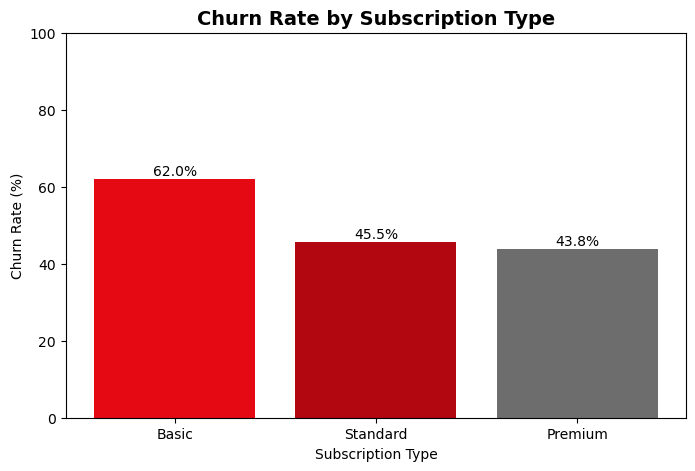

In [13]:
plot_data = subscription_churn.sort_values("churn_rate", ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(
    plot_data["subscription_type"],
    plot_data["churn_rate"],
    color=["#E50914", "#B20710", "#6D6D6D"]
)

plt.title("Churn Rate by Subscription Type", fontsize=14, fontweight="bold")
plt.xlabel("Subscription Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, plot_data["churn_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

### 5.2 Engagement and Churn

In [14]:
# Create last-login activity groups
netflix_clean["last_login_group"] = pd.cut(
    netflix_clean["last_login_days"],
    bins=[-1, 7, 21, 42, 60],
    labels=["0–7 days", "8–21 days", "22–42 days", "43–60 days"]
)

last_login_churn = (
    netflix_clean.groupby("last_login_group", observed=False)
    .agg(
        customers=("customer_id", "count"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

last_login_churn["churn_rate"] = last_login_churn["churn_rate"] * 100

last_login_churn

,last_login_group,customers,churn_rate
0,0–7 days,640,13.593750
1,8–21 days,1108,26.895307
2,22–42 days,1759,56.509380
3,43–60 days,1483,76.601483


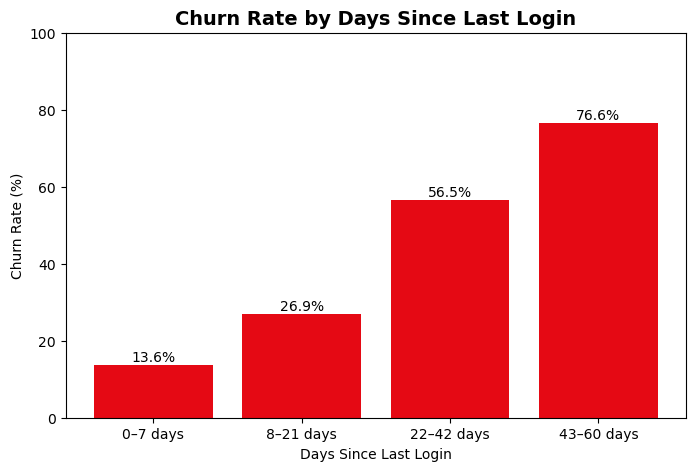

In [15]:
plt.figure(figsize=(8, 5))
bars = plt.bar(
    last_login_churn["last_login_group"].astype(str),
    last_login_churn["churn_rate"],
    color="#E50914"
)

plt.title("Churn Rate by Days Since Last Login", fontsize=14, fontweight="bold")
plt.xlabel("Days Since Last Login")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, last_login_churn["churn_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

In [16]:
netflix_clean["watch_hours_group"] = pd.cut(
    netflix_clean["watch_hours"],
    bins=[-0.01, 5, 10, 20, float("inf")],
    labels=["0–5 hours", "5–10 hours", "10–20 hours", "20+ hours"]
)

watch_hours_churn = (
    netflix_clean.groupby("watch_hours_group", observed=False)
    .agg(
        customers=("customer_id", "count"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

watch_hours_churn["churn_rate"] = watch_hours_churn["churn_rate"] * 100

watch_hours_churn

,watch_hours_group,customers,churn_rate
0,0–5 hours,1770,83.954802
1,5–10 hours,1150,44.347826
2,10–20 hours,1197,40.016708
3,20+ hours,873,4.581901


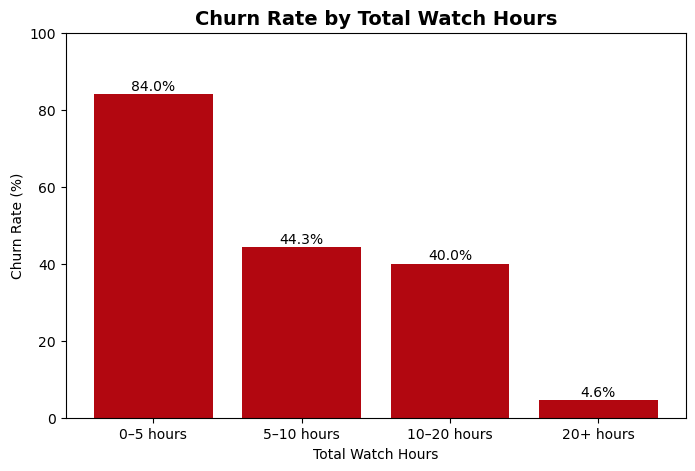

In [17]:
plt.figure(figsize=(8, 5))
bars = plt.bar(
    watch_hours_churn["watch_hours_group"].astype(str),
    watch_hours_churn["churn_rate"],
    color="#B20710"
)

plt.title("Churn Rate by Total Watch Hours", fontsize=14, fontweight="bold")
plt.xlabel("Total Watch Hours")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, watch_hours_churn["churn_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

### 5.3 Customer Characteristics and Churn

This analysis compares retained and churned customers across key numerical characteristics. It also examines churn rates by payment method and region to identify customer groups that may require targeted retention efforts.

In [18]:
numeric_columns = [
    "age",
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day"
]

retention_comparison = (
    netflix_clean.groupby("churned")[numeric_columns]
    .mean()
    .T
    .rename(columns={0: "Retained", 1: "Churned"})
)

retention_comparison["Difference (Churned - Retained)"] = (
    retention_comparison["Churned"] - retention_comparison["Retained"]
)

retention_comparison.round(2)

churned,Retained,Churned,Difference (Churned - Retained)
age,43.89,43.79,-0.09
watch_hours,17.35,5.92,-11.43
last_login_days,21.86,38.31,16.45
monthly_fee,14.25,13.13,-1.13
number_of_profiles,3.25,2.80,-0.45
avg_watch_time_per_day,1.44,0.16,-1.28


In [19]:
payment_churn = (
    netflix_clean.groupby("payment_method")
    .agg(
        customers=("customer_id", "count"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

payment_churn["churn_rate"] = payment_churn["churn_rate"] * 100
payment_churn = payment_churn.sort_values("churn_rate", ascending=False)

payment_churn

,payment_method,customers,churn_rate
1,Crypto,993,59.818731
3,Gift Card,973,57.965057
4,PayPal,1025,47.121951
2,Debit Card,1026,43.859649
0,Credit Card,973,43.576567


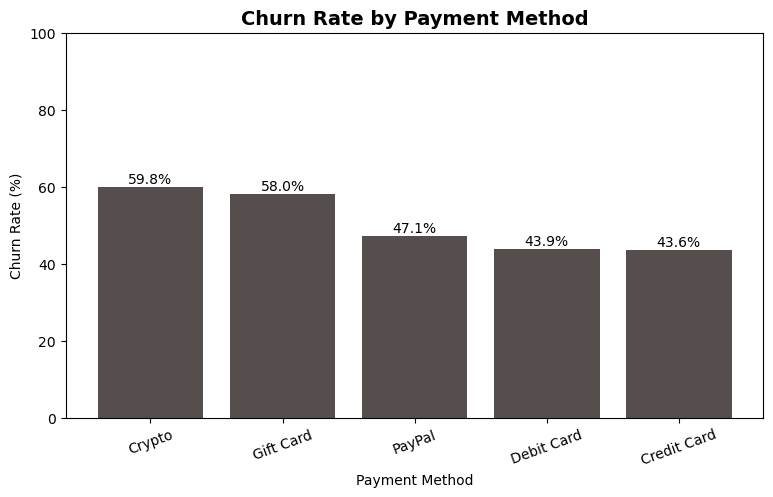

In [20]:
plt.figure(figsize=(9, 5))
bars = plt.bar(
    payment_churn["payment_method"],
    payment_churn["churn_rate"],
    color="#564D4D"
)

plt.title("Churn Rate by Payment Method", fontsize=14, fontweight="bold")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)
plt.xticks(rotation=20)

for bar, value in zip(bars, payment_churn["churn_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

In [21]:
region_churn = (
    netflix_clean.groupby("region")
    .agg(
        customers=("customer_id", "count"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

region_churn["churn_rate"] = region_churn["churn_rate"] * 100
region_churn = region_churn.sort_values("churn_rate", ascending=False)

region_churn

,region,customers,churn_rate
2,Europe,866,51.732102
5,South America,869,51.668585
1,Asia,839,50.774732
4,Oceania,764,50.130890
3,North America,849,49.587750
0,Africa,803,48.318804


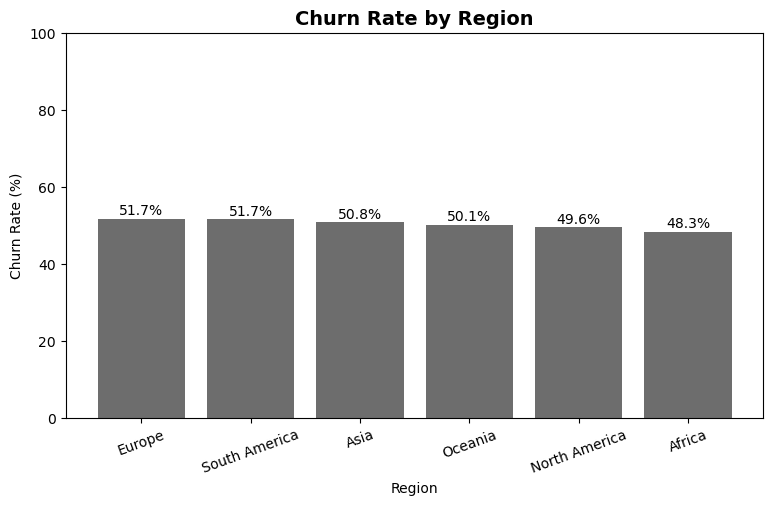

In [22]:
plt.figure(figsize=(9, 5))
bars = plt.bar(
    region_churn["region"],
    region_churn["churn_rate"],
    color="#6D6D6D"
)

plt.title("Churn Rate by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)
plt.xticks(rotation=20)

for bar, value in zip(bars, region_churn["churn_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

### 5.4 Membership Engagement Patterns

This table compares engagement and retention across Basic, Standard, and Premium subscribers. It provides evidence for identifying customer groups that may be suitable for membership upgrade offers.

In [23]:
membership_engagement = (
    netflix_clean.groupby("subscription_type")
    .agg(
        customers=("customer_id", "count"),
        churn_rate=("churned", "mean"),
        average_monthly_fee=("monthly_fee", "mean"),
        average_watch_hours=("watch_hours", "mean"),
        average_daily_watch_time=("avg_watch_time_per_day", "mean"),
        average_profiles=("number_of_profiles", "mean"),
        average_days_since_login=("last_login_days", "mean")
    )
    .reset_index()
)

membership_engagement["churn_rate"] = membership_engagement["churn_rate"] * 100

membership_engagement.round(2)

,subscription_type,customers,churn_rate,average_monthly_fee,average_watch_hours,average_daily_watch_time,average_profiles,average_days_since_login
0,Basic,1657,61.98,8.99,11.46,0.80,3.00,30.19
1,Premium,1690,43.79,17.99,11.67,0.81,3.07,30.14
2,Standard,1643,45.53,13.99,11.63,0.79,3.00,30.12


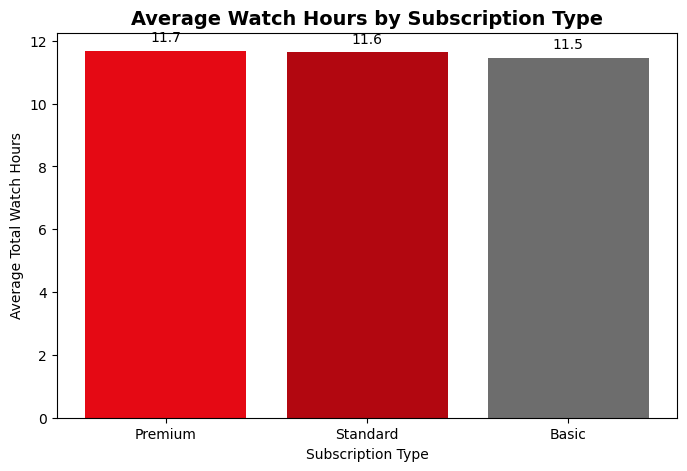

In [24]:
plot_data = membership_engagement.sort_values("average_watch_hours", ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(
    plot_data["subscription_type"],
    plot_data["average_watch_hours"],
    color=["#E50914", "#B20710", "#6D6D6D"]
)

plt.title("Average Watch Hours by Subscription Type", fontsize=14, fontweight="bold")
plt.xlabel("Subscription Type")
plt.ylabel("Average Total Watch Hours")

for bar, value in zip(bars, plot_data["average_watch_hours"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.3,
        f"{value:.1f}",
        ha="center"
    )

plt.show()

### 5.5 Advanced Engagement Analysis

The following visualizations examine the relationship between customer engagement, inactivity, subscription type, and churn in greater detail.

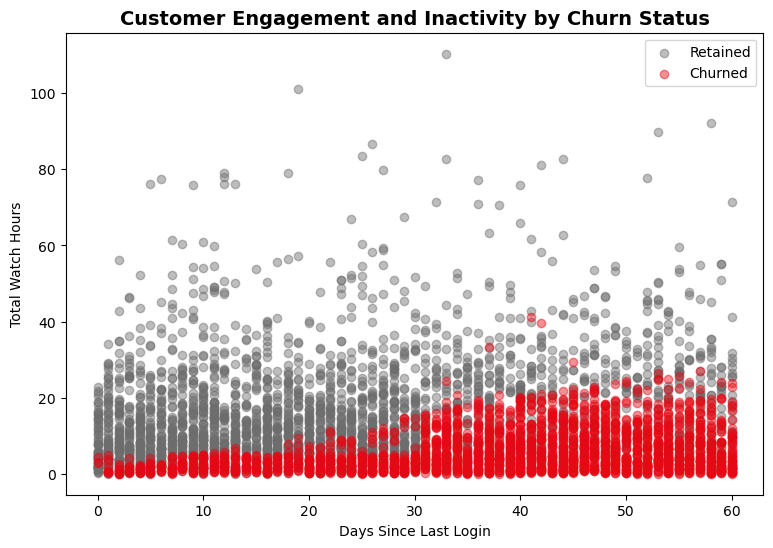

In [25]:
plt.figure(figsize=(9, 6))

colors = {0: "#6D6D6D", 1: "#E50914"}

for churn_value, label in [(0, "Retained"), (1, "Churned")]:
    subset = netflix_clean[netflix_clean["churned"] == churn_value]
    
    plt.scatter(
        subset["last_login_days"],
        subset["watch_hours"],
        alpha=0.45,
        color=colors[churn_value],
        label=label
    )

plt.title("Customer Engagement and Inactivity by Churn Status", fontsize=14, fontweight="bold")
plt.xlabel("Days Since Last Login")
plt.ylabel("Total Watch Hours")
plt.legend()
plt.show()

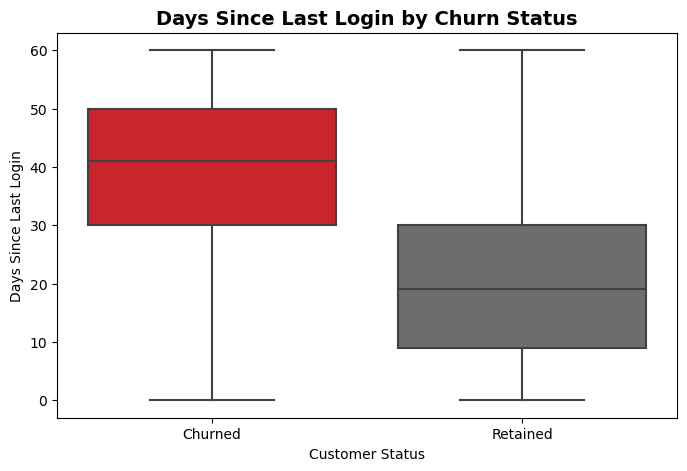

In [26]:
plot_data = netflix_clean.copy()
plot_data["churn_status"] = plot_data["churned"].map(
    {0: "Retained", 1: "Churned"}
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=plot_data,
    x="churn_status",
    y="last_login_days",
    palette={"Retained": "#6D6D6D", "Churned": "#E50914"}
)

plt.title("Days Since Last Login by Churn Status", fontsize=14, fontweight="bold")
plt.xlabel("Customer Status")
plt.ylabel("Days Since Last Login")
plt.show()

## 6. Feature Engineering

Additional customer engagement and value variables were created to improve churn analysis and predictive modeling. These variables capture viewing activity per profile, membership cost per profile, and customer inactivity risk.

In [56]:
# 1. Engagement per profile
netflix_clean["watch_hours_per_profile"] = (
    netflix_clean["watch_hours"] / netflix_clean["number_of_profiles"]
)

# 2. Membership cost per profile
netflix_clean["monthly_fee_per_profile"] = (
    netflix_clean["monthly_fee"] / netflix_clean["number_of_profiles"]
)

# 3. Inactivity-risk segment
netflix_clean["inactivity_risk"] = pd.cut(
    netflix_clean["last_login_days"],
    bins=[-1, 7, 21, 60],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# 4. Age group
netflix_clean["age_group"] = pd.cut(
    netflix_clean["age"],
    bins=[17, 29, 44, 59, 70],
    labels=["18–29", "30–44", "45–59", "60+"]
)

# Review the newly created variables
netflix_clean[
    [
        "watch_hours_per_profile",
        "monthly_fee_per_profile",
        "inactivity_risk",
        "age_group",
    ]
].head()

,watch_hours_per_profile,monthly_fee_per_profile,inactivity_risk,age_group
0,14.730,8.990,High Risk,45–59
1,0.140,2.798,Medium Risk,45–59
2,8.160,6.995,Medium Risk,18–29
3,2.255,8.995,Medium Risk,45–59
4,0.945,6.995,Medium Risk,45–59


In [28]:
new_features = [
    "watch_hours_per_profile",
    "monthly_fee_per_profile",
    "inactivity_risk",
    "age_group"
]

print(netflix_clean[new_features].isnull().sum())

for column in ["inactivity_risk", "age_group"]:
    print(f"\n{column}")
    print(netflix_clean[column].value_counts())

watch_hours_per_profile    0
monthly_fee_per_profile    0
inactivity_risk            0
age_group                  0
dtype: int64

inactivity_risk
inactivity_risk
High Risk      3242
Medium Risk    1108
Low Risk        640
Name: count, dtype: int64

age_group
age_group
45–59    1396
30–44    1370
18–29    1180
60+      1044
Name: count, dtype: int64


### 6.1 Feature-Engineering Visualizations

These visualizations examine whether the engineered features reveal meaningful differences in churn risk, engagement, and customer value.

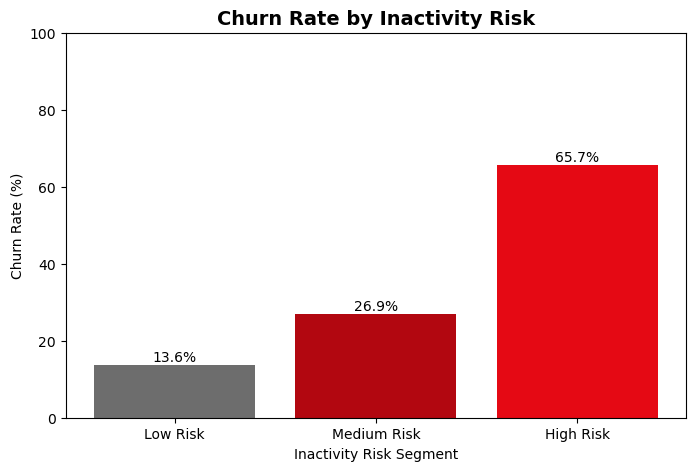

In [29]:
inactivity_churn = (
    netflix_clean.groupby("inactivity_risk", observed=False)
    .agg(
        customers=("customer_id", "count"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

inactivity_churn["churn_rate"] = inactivity_churn["churn_rate"] * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(
    inactivity_churn["inactivity_risk"].astype(str),
    inactivity_churn["churn_rate"],
    color=["#6D6D6D", "#B20710", "#E50914"]
)

plt.title("Churn Rate by Inactivity Risk", fontsize=14, fontweight="bold")
plt.xlabel("Inactivity Risk Segment")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, inactivity_churn["churn_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

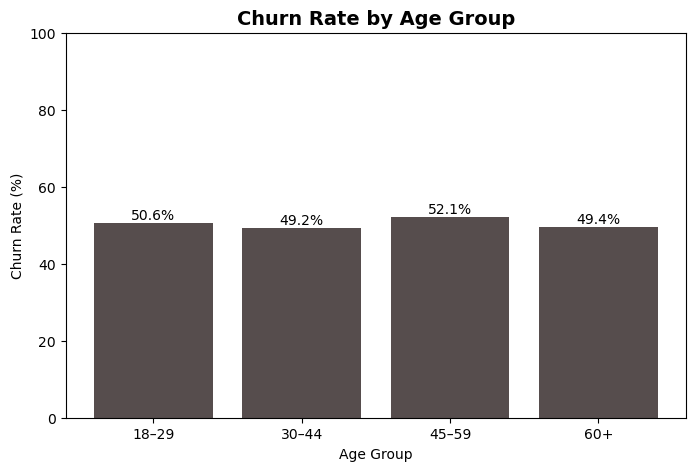

In [30]:
age_churn = (
    netflix_clean.groupby("age_group", observed=False)
    .agg(
        customers=("customer_id", "count"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

age_churn["churn_rate"] = age_churn["churn_rate"] * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(
    age_churn["age_group"].astype(str),
    age_churn["churn_rate"],
    color="#564D4D"
)

plt.title("Churn Rate by Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, age_churn["churn_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

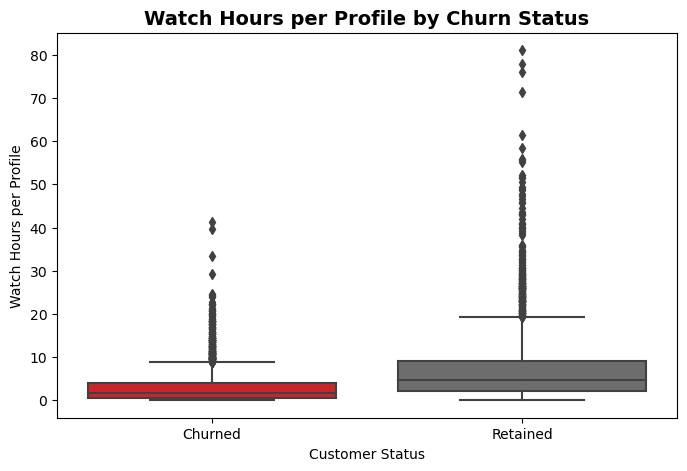

In [31]:
feature_plot_data = netflix_clean.copy()
feature_plot_data["churn_status"] = feature_plot_data["churned"].map(
    {0: "Retained", 1: "Churned"}
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=feature_plot_data,
    x="churn_status",
    y="watch_hours_per_profile",
    palette={"Retained": "#6D6D6D", "Churned": "#E50914"}
)

plt.title("Watch Hours per Profile by Churn Status", fontsize=14, fontweight="bold")
plt.xlabel("Customer Status")
plt.ylabel("Watch Hours per Profile")
plt.show()

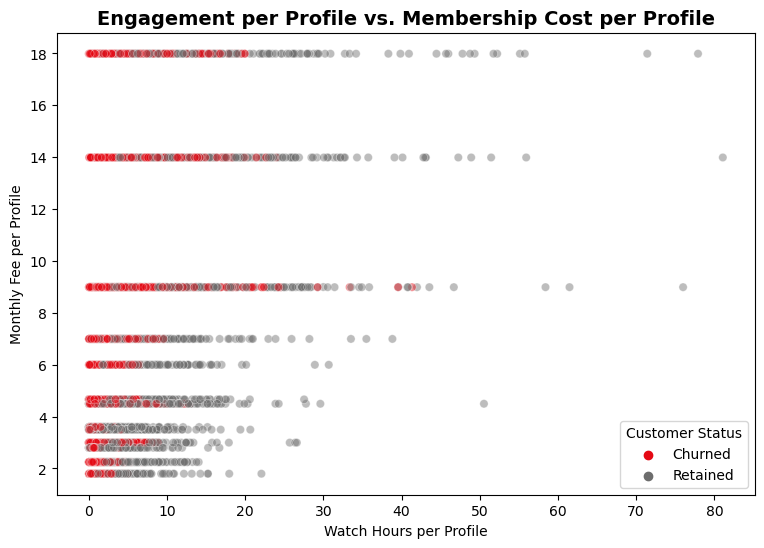

In [32]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=feature_plot_data,
    x="watch_hours_per_profile",
    y="monthly_fee_per_profile",
    hue="churn_status",
    palette={"Retained": "#6D6D6D", "Churned": "#E50914"},
    alpha=0.45
)

plt.title("Engagement per Profile vs. Membership Cost per Profile", fontsize=14, fontweight="bold")
plt.xlabel("Watch Hours per Profile")
plt.ylabel("Monthly Fee per Profile")
plt.legend(title="Customer Status")
plt.show()

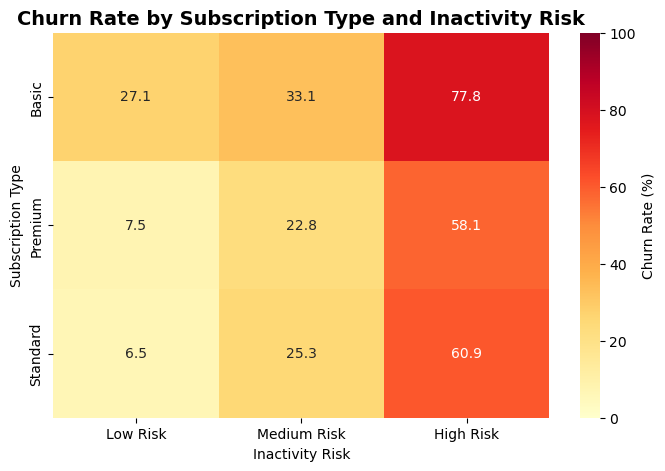

In [33]:
plan_inactivity_churn = (
    netflix_clean.pivot_table(
        index="subscription_type",
        columns="inactivity_risk",
        values="churned",
        aggfunc="mean",
        observed=False
    ) * 100
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    plan_inactivity_churn,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Churn Rate (%)"}
)

plt.title("Churn Rate by Subscription Type and Inactivity Risk", fontsize=14, fontweight="bold")
plt.xlabel("Inactivity Risk")
plt.ylabel("Subscription Type")
plt.show()

## 7. Predictive Analytics: Churn-Risk Modeling

This section develops a predictive model to estimate each current subscriber’s likelihood of churning. The model will use customer demographics, subscription information, engagement behavior, payment information, and engineered features. The resulting churn-risk scores will support targeted retention actions and will also help distinguish customers who should receive retention outreach from customers who may be suitable for upgrade offers.

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [35]:
# Define model features and churn target

numeric_features = [
    "age",
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day",
    "watch_hours_per_profile",
    "monthly_fee_per_profile"
]

categorical_features = [
    "gender",
    "subscription_type",
    "region",
    "device",
    "payment_method",
    "favorite_genre"
]

model_features = numeric_features + categorical_features

X = netflix_clean[model_features]
y = netflix_clean["churned"]

# Use 80% of records to train the models and 20% to test them.
# stratify=y keeps the churn rate similar in both groups.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])
print(f"Training churn rate: {y_train.mean() * 100:.1f}%")
print(f"Testing churn rate: {y_test.mean() * 100:.1f}%")

Training records: 3992
Testing records: 998
Training churn rate: 50.4%
Testing churn rate: 50.4%


### 7.1 Logistic Regression Model

Logistic regression is used as the first churn-prediction model because it is interpretable and produces a probability that each customer will churn. Numeric variables are standardized, while categorical variables are converted into model-readable columns through one-hot encoding.

In [36]:
# Prepare numeric and categorical features for logistic regression

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Build and train the logistic regression model
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'watch_hours',
                                                   'last_login_days',
                                                   'monthly_fee',
                                                   'number_of_profiles',
                                                   'avg_watch_time_per_day',
                                                   'watch_hours_per_profile',
                                                   'monthly_fee_per_profile']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender',
                                                   'subscription_type',
                                                   'region', 'device',
                                                   'payment_method',
                                                   'favorite_genre'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [37]:
# Evaluate logistic regression on the unseen test data
y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

logistic_results = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
        "Score": [
            accuracy_score(y_test, y_pred_logistic),
            precision_score(y_test, y_pred_logistic),
            recall_score(y_test, y_pred_logistic),
            f1_score(y_test, y_pred_logistic),
            roc_auc_score(y_test, y_prob_logistic)
        ]
    }
)

logistic_results["Score"] = logistic_results["Score"].round(3)
logistic_results

,Metric,Score
0,Accuracy,0.894
1,Precision,0.890
2,Recall,0.901
3,F1 Score,0.895
4,ROC-AUC,0.965


### 7.2 Logistic Regression Evaluation

The logistic regression model performed strongly on the unseen test dataset. Recall is especially important because the business wants to identify as many customers at risk of churn as possible before they cancel.

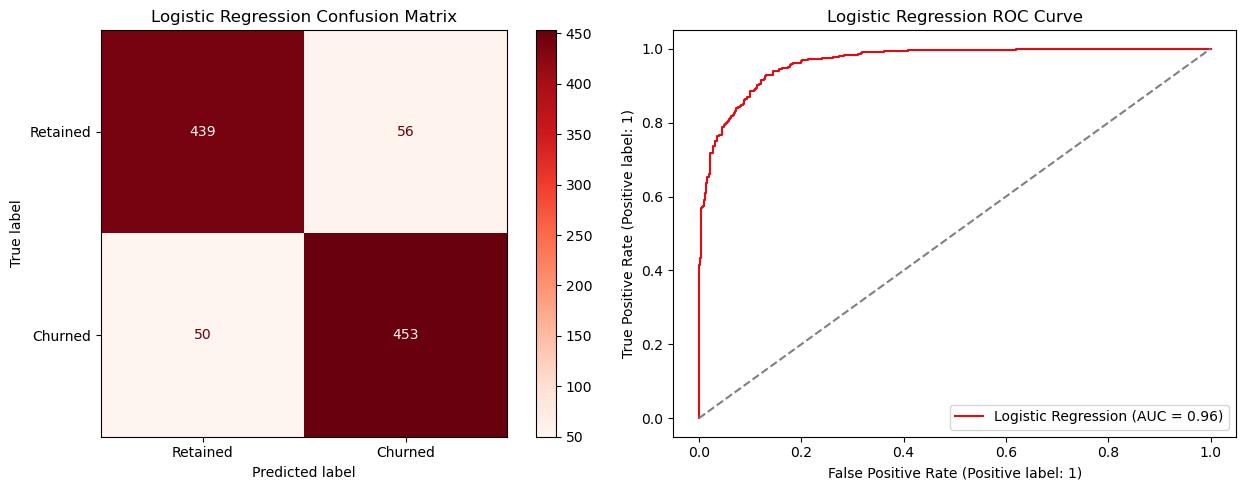

In [38]:
# Confusion matrix and ROC curve for logistic regression
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    display_labels=["Retained", "Churned"],
    cmap="Reds",
    ax=axes[0]
)
axes[0].set_title("Logistic Regression Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_logistic,
    name="Logistic Regression",
    color="#E50914",
    ax=axes[1]
)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("Logistic Regression ROC Curve")

plt.tight_layout()
plt.show()

### 7.3 Random Forest Model

A random forest classifier is used as a second model because it can identify more complex and non-linear relationships between customer characteristics, engagement behaviors, and churn. Its performance will be compared with logistic regression using the same test dataset.

In [39]:
# Build and train the random forest model

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=3,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'watch_hours',
                                                   'last_login_days',
                                                   'monthly_fee',
                                                   'number_of_profiles',
                                                   'avg_watch_time_per_day',
                                                   'watch_hours_per_profile',
                                                   'monthly_fee_per_profile']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender',
                                                   'subscription_type',
                                                   'region', 'device',
                                                   'payment_method',
                                                   'favorite_genre'])])),
                ('model',
                 RandomForestClassifier(min_samples_leaf=3, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [40]:
# Evaluate random forest on the same unseen test data
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

random_forest_results = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
        "Score": [
            accuracy_score(y_test, y_pred_rf),
            precision_score(y_test, y_pred_rf),
            recall_score(y_test, y_pred_rf),
            f1_score(y_test, y_pred_rf),
            roc_auc_score(y_test, y_prob_rf)
        ]
    }
)

random_forest_results["Score"] = random_forest_results["Score"].round(3)

model_comparison = logistic_results.merge(
    random_forest_results,
    on="Metric",
    suffixes=("_Logistic", "_Random_Forest")
)

model_comparison

,Metric,Score_Logistic,Score_Random_Forest
0,Accuracy,0.894,0.985
1,Precision,0.890,0.988
2,Recall,0.901,0.982
3,F1 Score,0.895,0.985
4,ROC-AUC,0.965,0.999


### 7.4 Model Selection

The random forest model outperformed logistic regression across all evaluation measures and was selected as the final churn-prediction model. It achieved a recall of 98.2%, meaning it identified most customers who actually churned in the test dataset. Because the dataset is synthetic, this strong result should be interpreted as model performance within this dataset rather than a guaranteed real-world result.

In [41]:
# Identify the most important features in the random forest model

feature_names = random_forest_model.named_steps[
    "preprocessor"
].get_feature_names_out()

feature_importance = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": random_forest_model.named_steps[
            "model"
        ].feature_importances_
    }
).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
5,num__avg_watch_time_per_day,0.336225
2,num__last_login_days,0.188645
1,num__watch_hours,0.173649
6,num__watch_hours_per_profile,0.087745
4,num__number_of_profiles,0.041919
7,num__monthly_fee_per_profile,0.036716
11,cat__subscription_type_Basic,0.017869
3,num__monthly_fee,0.017352
26,cat__payment_method_Crypto,0.016666
28,cat__payment_method_Gift Card,0.014236


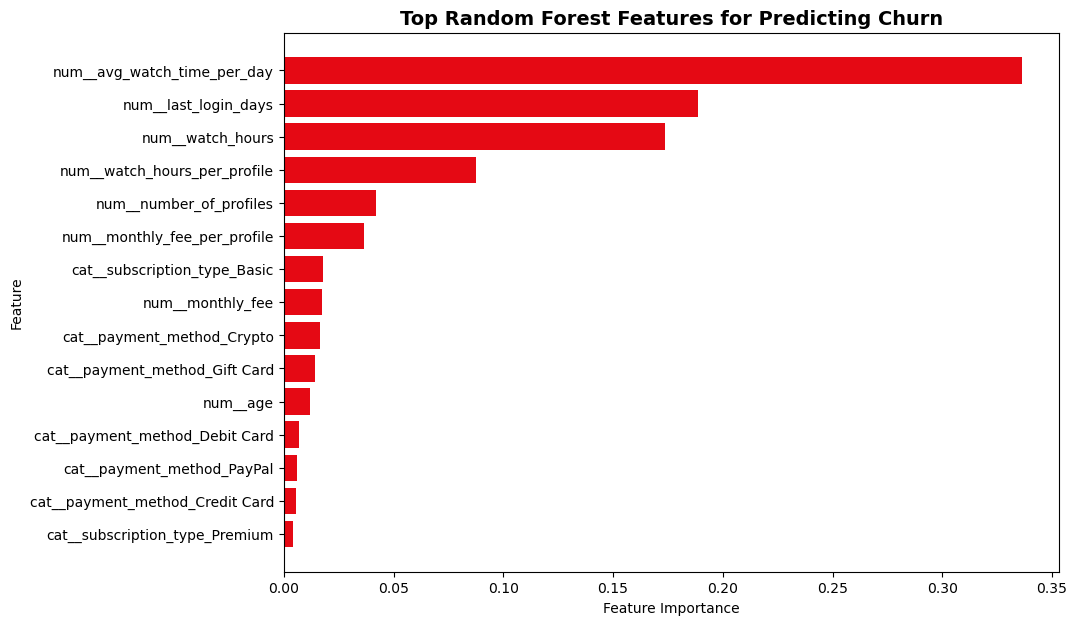

In [42]:
# Plot the 15 most important churn-prediction features
top_features = feature_importance.head(15).sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["feature"],
    top_features["importance"],
    color="#E50914"
)

plt.title("Top Random Forest Features for Predicting Churn", fontsize=14, fontweight="bold")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

### 7.5 Final Churn-Risk Scores

After selecting the random forest model, the model is retrained using the full cleaned dataset. Each customer is assigned a churn probability and categorized into a low-, medium-, or high-risk segment. These scores will support the retention and upgrade recommendations in the prescriptive analytics section.

In [43]:
# Retrain the selected random forest model using all cleaned customer data

final_random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=3,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

final_random_forest_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'watch_hours',
                                                   'last_login_days',
                                                   'monthly_fee',
                                                   'number_of_profiles',
                                                   'avg_watch_time_per_day',
                                                   'watch_hours_per_profile',
                                                   'monthly_fee_per_profile']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender',
                                                   'subscription_type',
                                                   'region', 'device',
                                                   'payment_method',
                                                   'favorite_genre'])])),
                ('model',
                 RandomForestClassifier(min_samples_leaf=3, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [44]:
# Score all customers with churn probabilities and risk segments

netflix_scored = netflix_clean.copy()

netflix_scored["churn_probability"] = (
    final_random_forest_model.predict_proba(
        netflix_scored[model_features]
    )[:, 1]
)

netflix_scored["churn_risk_segment"] = pd.cut(
    netflix_scored["churn_probability"],
    bins=[-0.01, 0.25, 0.65, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

risk_summary = (
    netflix_scored.groupby("churn_risk_segment", observed=False)
    .agg(
        customers=("customer_id", "count"),
        average_churn_probability=("churn_probability", "mean"),
        average_watch_hours=("watch_hours", "mean"),
        average_days_since_login=("last_login_days", "mean")
    )
    .reset_index()
)

risk_summary["average_churn_probability"] = (
    risk_summary["average_churn_probability"] * 100
)

risk_summary.round(2)

,churn_risk_segment,customers,average_churn_probability,average_watch_hours,average_days_since_login
0,Low Risk,2397,5.25,17.65,21.71
1,Medium Risk,123,41.43,11.09,27.36
2,High Risk,2470,94.72,5.74,38.48


## 8. Prescriptive Analytics and Business Recommendations

This section converts the predictive churn results and customer segments into recommended business actions. The recommendations focus on retaining at-risk subscribers, identifying upgrade opportunities among current members, and defining high-value customer profiles for future acquisition targeting.

### 8.1 Retention Strategy: Prioritizing Revenue at Risk

Churn probabilities are combined with monthly subscription fees to estimate expected monthly revenue at risk. This allows the streaming service to prioritize retention outreach toward customers who are both likely to churn and financially valuable.

In [45]:
# Estimate expected monthly revenue at risk for each customer
netflix_scored["expected_monthly_revenue_at_risk"] = (
    netflix_scored["monthly_fee"] * netflix_scored["churn_probability"]
)

# Summarize revenue at risk by churn-risk segment
retention_summary = (
    netflix_scored.groupby("churn_risk_segment", observed=False)
    .agg(
        customers=("customer_id", "count"),
        average_churn_probability=("churn_probability", "mean"),
        total_monthly_revenue=("monthly_fee", "sum"),
        expected_monthly_revenue_at_risk=(
            "expected_monthly_revenue_at_risk",
            "sum"
        ),
        average_watch_hours=("watch_hours", "mean"),
        average_days_since_login=("last_login_days", "mean")
    )
    .reset_index()
)

retention_summary["average_churn_probability"] = (
    retention_summary["average_churn_probability"] * 100
)

retention_summary.round(2)

,churn_risk_segment,customers,average_churn_probability,total_monthly_revenue,expected_monthly_revenue_at_risk,average_watch_hours,average_days_since_login
0,Low Risk,2397,5.25,34230.03,1775.79,17.65,21.71
1,Medium Risk,123,41.43,1594.77,655.41,11.09,27.36
2,High Risk,2470,94.72,32460.30,30670.98,5.74,38.48


In [46]:
# Customers to prioritize for retention outreach
high_risk_retention_list = (
    netflix_scored[
        netflix_scored["churn_risk_segment"] == "High Risk"
    ][
        [
            "customer_id",
            "subscription_type",
            "monthly_fee",
            "watch_hours",
            "last_login_days",
            "churn_probability",
            "expected_monthly_revenue_at_risk"
        ]
    ]
    .sort_values(
        "expected_monthly_revenue_at_risk",
        ascending=False
    )
)

high_risk_retention_list.head(10)

,customer_id,subscription_type,monthly_fee,watch_hours,last_login_days,churn_probability,expected_monthly_revenue_at_risk
2109,97bb6237-30a3-4795-b9dd-036113d4b3b3,Premium,17.99,0.97,49,1.000000,17.990000
2004,aef0ea56-6758-44c7-88b6-32d7ca0556ca,Premium,17.99,1.46,35,1.000000,17.990000
2692,fcf7205d-ed92-45a1-a608-75f6a70e5ed7,Premium,17.99,0.62,39,0.999141,17.974554
258,7b0bee97-a383-498d-a1d0-2de7c824ce74,Premium,17.99,3.55,45,0.998889,17.970011
3547,1bbee03c-aa9a-43ba-a760-10d789b2bb68,Premium,17.99,2.25,53,0.998889,17.970011
3225,5843bccd-c8a2-4294-b541-85481a633beb,Premium,17.99,2.28,47,0.998778,17.968012
4674,938fec83-206c-4bb3-8ae6-7aa0bd8e7683,Premium,17.99,2.59,56,0.998552,17.963943
707,7d921bf8-61ef-4609-a46e-96d832d0d04e,Premium,17.99,2.73,45,0.998524,17.963443
4876,c97606a8-478f-4114-aca0-fa17084ef4b3,Premium,17.99,2.62,37,0.998381,17.960873
564,0d6dae1e-d44c-425b-abf5-371bb1a033db,Premium,17.99,1.41,33,0.998333,17.960017


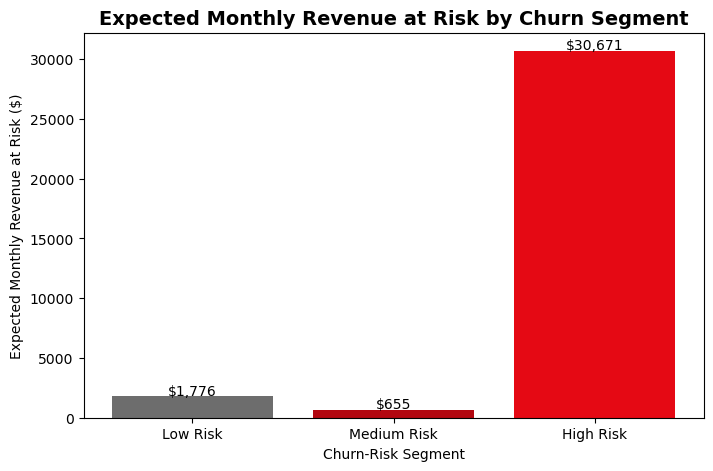

In [47]:
# Expected monthly revenue at risk by churn-risk segment
plot_data = retention_summary.copy()

plt.figure(figsize=(8, 5))
bars = plt.bar(
    plot_data["churn_risk_segment"].astype(str),
    plot_data["expected_monthly_revenue_at_risk"],
    color=["#6D6D6D", "#B20710", "#E50914"]
)

plt.title("Expected Monthly Revenue at Risk by Churn Segment", fontsize=14, fontweight="bold")
plt.xlabel("Churn-Risk Segment")
plt.ylabel("Expected Monthly Revenue at Risk ($)")

for bar, value in zip(bars, plot_data["expected_monthly_revenue_at_risk"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 100,
        f"${value:,.0f}",
        ha="center"
    )

plt.show()

### 8.2 Upgrade Strategy: Identifying High-Opportunity Subscribers

The dataset does not include historical plan upgrades or offer-acceptance outcomes, so an upgrade-prediction model cannot be built reliably. Instead, a data-driven prioritization score is used to identify current Basic and Standard subscribers who are low churn risk, highly engaged, active, and likely to benefit from a higher-tier plan.

In [48]:
# Create the pool of eligible upgrade candidates:
# Current Basic/Standard subscribers with low churn risk

upgrade_pool = netflix_scored[
    (netflix_scored["subscription_type"].isin(["Basic", "Standard"])) &
    (netflix_scored["churn_risk_segment"] == "Low Risk")
].copy()

# Create percentile scores within the eligible customer pool
# Higher engagement and more profiles increase upgrade opportunity.
# Fewer days since login also increase upgrade opportunity.

upgrade_pool["engagement_percentile"] = (
    upgrade_pool["watch_hours_per_profile"].rank(pct=True)
)

upgrade_pool["profiles_percentile"] = (
    upgrade_pool["number_of_profiles"].rank(pct=True)
)

upgrade_pool["recency_percentile"] = (
    1 - upgrade_pool["last_login_days"].rank(pct=True)
)

# Weighted upgrade-opportunity score
upgrade_pool["upgrade_opportunity_score"] = (
    0.50 * upgrade_pool["engagement_percentile"] +
    0.30 * upgrade_pool["profiles_percentile"] +
    0.20 * upgrade_pool["recency_percentile"]
) * 100

# Target the top 25% of eligible subscribers
upgrade_cutoff = upgrade_pool["upgrade_opportunity_score"].quantile(0.75)

upgrade_candidates = upgrade_pool[
    upgrade_pool["upgrade_opportunity_score"] >= upgrade_cutoff
].copy()

print("Eligible Basic/Standard low-risk subscribers:", len(upgrade_pool))
print("Top upgrade candidates:", len(upgrade_candidates))
print(f"Upgrade score cutoff: {upgrade_cutoff:.1f}")

Eligible Basic/Standard low-risk subscribers: 1473
Top upgrade candidates: 369
Upgrade score cutoff: 57.2


In [49]:
# Summary of recommended upgrade candidates by current plan
upgrade_summary = (
    upgrade_candidates.groupby("subscription_type")
    .agg(
        candidates=("customer_id", "count"),
        average_upgrade_score=("upgrade_opportunity_score", "mean"),
        average_watch_hours_per_profile=("watch_hours_per_profile", "mean"),
        average_profiles=("number_of_profiles", "mean"),
        average_days_since_login=("last_login_days", "mean")
    )
    .reset_index()
)

upgrade_summary.round(2)

,subscription_type,candidates,average_upgrade_score,average_watch_hours_per_profile,average_profiles,average_days_since_login
0,Basic,180,64.20,14.55,3.05,15.94
1,Standard,189,63.65,14.17,3.01,18.08


In [50]:
# Highest-priority customers for an upgrade offer
upgrade_candidates[
    [
        "customer_id",
        "subscription_type",
        "watch_hours_per_profile",
        "number_of_profiles",
        "last_login_days",
        "churn_probability",
        "upgrade_opportunity_score"
    ]
].sort_values(
    "upgrade_opportunity_score",
    ascending=False
).head(10)

,customer_id,subscription_type,watch_hours_per_profile,number_of_profiles,last_login_days,churn_probability,upgrade_opportunity_score
3933,2fe53083-6764-4dc3-bbaa-a88e030e71e2,Standard,15.2580,5,5,0.011349,86.860149
4338,72a2c300-cc3d-4e71-81e6-85e4e309c680,Basic,15.2400,5,12,0.003833,83.058384
3446,c6a8e5fa-5432-47ce-b361-ae6096451a27,Basic,15.2320,5,13,0.006619,82.576375
2250,ee89f93f-b2ff-459e-93a2-ea8bfa7992f6,Basic,12.1700,5,10,0.001553,81.408690
2281,cb5d5d80-7f94-421c-a76a-fb560beeb1ba,Standard,19.3925,4,6,0.000000,81.378140
997,86f4f231-f362-43d5-91ca-d0045caa2ba6,Basic,14.0600,4,2,0.006632,80.495587
714,4d040be6-2b36-4f59-ba9c-b92c8c683a5f,Basic,10.7960,5,10,0.001333,79.813306
1126,75356eca-46e2-4c47-8f88-59c4646c5827,Basic,10.9120,5,11,0.006103,79.385608
3753,827b839a-2a40-41e8-a668-3e84708aab8d,Basic,9.4800,5,9,0.000667,78.078751
3285,2774bcf2-ddec-44c9-a3bc-ff87a8a96dee,Standard,16.7100,5,25,0.001333,77.926001


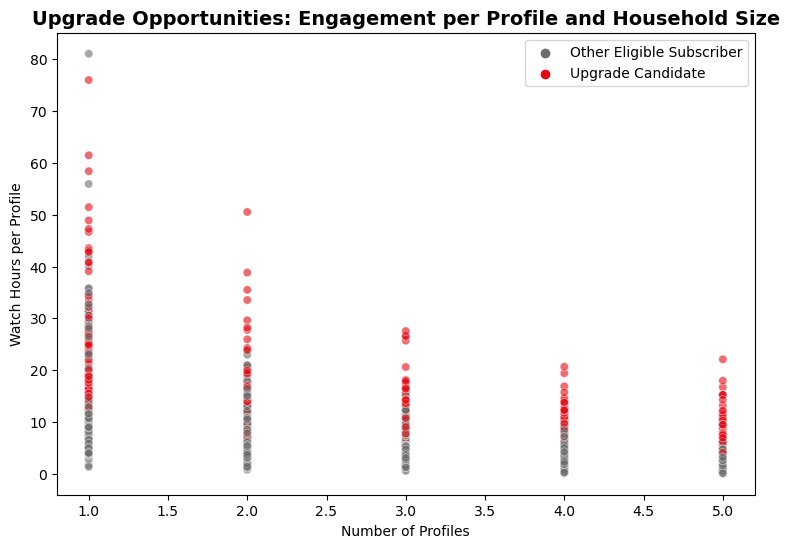

In [51]:
# Visualize engagement and household size for upgrade candidates
upgrade_pool["upgrade_recommendation"] = np.where(
    upgrade_pool["upgrade_opportunity_score"] >= upgrade_cutoff,
    "Upgrade Candidate",
    "Other Eligible Subscriber"
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=upgrade_pool,
    x="number_of_profiles",
    y="watch_hours_per_profile",
    hue="upgrade_recommendation",
    palette={
        "Other Eligible Subscriber": "#6D6D6D",
        "Upgrade Candidate": "#E50914"
    },
    alpha=0.60
)

plt.title("Upgrade Opportunities: Engagement per Profile and Household Size",
          fontsize=14, fontweight="bold")
plt.xlabel("Number of Profiles")
plt.ylabel("Watch Hours per Profile")
plt.legend(title="")
plt.show()

### 8.3 Acquisition Strategy: Defining a Retained High-Value Customer Profile

Because the dataset contains only existing subscribers, acquisition cannot be predicted directly. Instead, historical retained customers are used to define a high-value profile for lookalike advertising, referral campaigns, and free-trial targeting. High-value customers are defined as retained, low-risk subscribers in the top 25% for both monthly fee and engagement per profile.

In [52]:
# Identify retained, high-value customers for acquisition targeting

# Use only historically retained, low-risk customers to build the profile
retained_low_risk = netflix_scored[
    (netflix_scored["churned"] == 0) &
    (netflix_scored["churn_risk_segment"] == "Low Risk")
].copy()

# Define high value using the top 25% of retained, low-risk customers
monthly_fee_cutoff = retained_low_risk["monthly_fee"].quantile(0.75)
engagement_cutoff = retained_low_risk["watch_hours_per_profile"].quantile(0.75)

high_value_mask = (
    (netflix_scored["churned"] == 0) &
    (netflix_scored["churn_risk_segment"] == "Low Risk") &
    (netflix_scored["monthly_fee"] >= monthly_fee_cutoff) &
    (netflix_scored["watch_hours_per_profile"] >= engagement_cutoff)
)

# Add the acquisition segment directly to the final scored dataset
netflix_scored["acquisition_segment"] = "Other Customer"
netflix_scored.loc[
    high_value_mask,
    "acquisition_segment"
] = "Retained High-Value Customer"

high_value_retained = netflix_scored[
    netflix_scored["acquisition_segment"] == "Retained High-Value Customer"
].copy()

print("Retained, low-risk customers:", len(retained_low_risk))
print("Retained, high-value customers:", len(high_value_retained))
print(f"Monthly-fee cutoff: ${monthly_fee_cutoff:.2f}")
print(f"Engagement-per-profile cutoff: {engagement_cutoff:.2f}")

Retained, low-risk customers: 2397
Retained, high-value customers: 202
Monthly-fee cutoff: $17.99
Engagement-per-profile cutoff: 9.15


In [53]:
# Numerical profile of retained, high-value customers
acquisition_profile_summary = pd.DataFrame(
    {
        "Metric": [
            "Customers",
            "Average age",
            "Average monthly fee",
            "Average watch hours per profile",
            "Average number of profiles",
            "Average days since login",
            "Average churn probability"
        ],
        "Value": [
            len(high_value_retained),
            high_value_retained["age"].mean(),
            high_value_retained["monthly_fee"].mean(),
            high_value_retained["watch_hours_per_profile"].mean(),
            high_value_retained["number_of_profiles"].mean(),
            high_value_retained["last_login_days"].mean(),
            high_value_retained["churn_probability"].mean() * 100
        ]
    }
)

acquisition_profile_summary["Value"] = acquisition_profile_summary["Value"].round(2)
acquisition_profile_summary

,Metric,Value
0,Customers,202.00
1,Average age,42.79
2,Average monthly fee,17.99
3,Average watch hours per profile,19.00
4,Average number of profiles,1.90
5,Average days since login,25.80
6,Average churn probability,2.36


In [54]:
# Most common categorical traits among retained, high-value customers
profile_columns = ["age_group", "region", "device", "favorite_genre"]

top_traits = []

for column in profile_columns:
    top_value = high_value_retained[column].mode()[0]
    top_share = (
        high_value_retained[column]
        .value_counts(normalize=True)
        .iloc[0] * 100
    )
    
    top_traits.append(
        {
            "Customer Characteristic": column.replace("_", " ").title(),
            "Most Common Value": top_value,
            "Share of High-Value Customers (%)": round(top_share, 1)
        }
    )

top_customer_traits = pd.DataFrame(top_traits)
top_customer_traits

,Customer Characteristic,Most Common Value,Share of High-Value Customers (%)
0,Age Group,18–29,28.2
1,Region,Africa,20.3
2,Device,Desktop,21.8
3,Favorite Genre,Romance,16.3


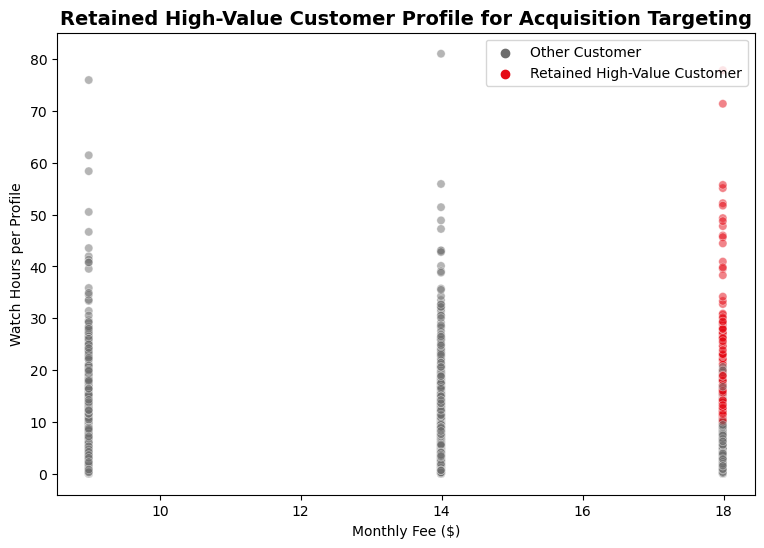

In [55]:
# Visualize the retained high-value acquisition profile
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=netflix_scored,
    x="monthly_fee",
    y="watch_hours_per_profile",
    hue="acquisition_segment",
    palette={
        "Other Customer": "#6D6D6D",
        "Retained High-Value Customer": "#E50914"
    },
    alpha=0.50
)

plt.title(
    "Retained High-Value Customer Profile for Acquisition Targeting",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Monthly Fee ($)")
plt.ylabel("Watch Hours per Profile")
plt.legend(title="")
plt.show()

### 8.4 Recommended Actions and Measurement Plan

- **Retention:** Prioritize high-risk customers by expected monthly revenue at risk. Use personalized content recommendations, re-engagement messages, and targeted retention offers for customers with low engagement and long periods since login.

- **Upgrade:** Offer a Premium trial or targeted upgrade message to the highest-scoring Basic and Standard subscribers. These customers are low churn risk, active, highly engaged per profile, and have multiple profiles.

- **Acquisition:** Target lookalike audiences who resemble retained high-value customers. Use the identified high-value profile to guide advertising audiences, referral campaigns, and free-trial promotions.